## Objetivo

O objetivo da análise exploratória de dados (EDA) é compreender melhor o conjunto de dados, investigando sua estrutura, distribuição e possíveis padrões. Além disso, busca-se identificar relações entre variáveis, detectar outliers e avaliar quais características podem impactar positiva ou negativamente o desempenho dos modelos de predição para o target **SalePrice** (o preço final de um imóvel dado um conjunto de características).

In [42]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd
import seaborn as sns

In [13]:
df = pd.read_csv('../data/train.csv', sep=',')

In [18]:
df = df.drop('Id', axis=1)

In [19]:
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   str    
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   str    
 5   Alley          91 non-null     str    
 6   LotShape       1460 non-null   str    
 7   LandContour    1460 non-null   str    
 8   Utilities      1460 non-null   str    
 9   LotConfig      1460 non-null   str    
 10  LandSlope      1460 non-null   str    
 11  Neighborhood   1460 non-null   str    
 12  Condition1     1460 non-null   str    
 13  Condition2     1460 non-null   str    
 14  BldgType       1460 non-null   str    
 15  HouseStyle     1460 non-null   str    
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt      1460

Como primeira etapa, identificaremos o comportamento da distribuição dos dados do target 'SalePrice'. Um dado $x_i$ é um outlier se:

$$x_i < Q_1 - 1.5 \times \text{IQR}$$

ou 

$$x_i > Q_3 + 1.5 \times \text{IQR}$$

onde $\text{IQR}$ é a distância inter-quartil: 

$$\text{IQR} = Q_3 - Q_1$$

In [54]:
Q1 = df['SalePrice'].quantile(0.25)
Q3 = df['SalePrice'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[(df["SalePrice"] < limite_inferior) | (df["SalePrice"] > limite_superior)]

print("Q1: ", Q1)
print("Q3: ", Q3)
print("IQR: ", Q3 - Q1)

outliers

Q1:  129975.0
Q3:  214000.0
IQR:  84025.0


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
11,60,RL,85.0,11924,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,7,2006,New,Partial,345000
53,20,RL,68.0,50271,Pave,NaN,IR1,Low,AllPub,Inside,...,0,NaN,NaN,NaN,0,11,2006,WD,Normal,385000
58,60,RL,66.0,13682,Pave,NaN,IR2,HLS,AllPub,CulDSac,...,0,NaN,NaN,NaN,0,10,2006,New,Partial,438780
112,60,RL,77.0,9965,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,10,2007,New,Partial,383970
151,20,RL,107.0,13891,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,1,2008,New,Partial,372402
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1268,50,RL,NaN,14100,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,GdWo,NaN,0,5,2008,WD,Normal,381000
1353,50,RL,56.0,14720,Pave,NaN,IR1,Lvl,AllPub,CulDSac,...,0,NaN,NaN,NaN,0,3,2010,WD,Normal,410000
1373,20,RL,NaN,11400,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,3,2007,WD,Normal,466500
1388,20,RL,42.0,14892,Pave,NaN,IR1,HLS,AllPub,CulDSac,...,0,NaN,NaN,NaN,0,10,2009,WD,Normal,377500


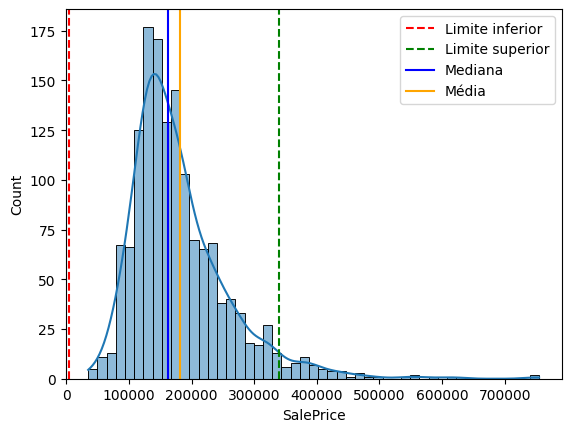

In [63]:
sns.histplot(data=df, x='SalePrice', kde=True)

plt.axvline(limite_inferior, color='red', linestyle='--', label='Limite inferior')
plt.axvline(limite_superior, color='green', linestyle='--', label='Limite superior')
plt.axvline(df['SalePrice'].median(), color='blue', linestyle='-', label='Mediana')
plt.axvline(df['SalePrice'].mean(), color='orange', linestyle='-', label='Média')

plt.legend()
plt.show()

<Axes: >

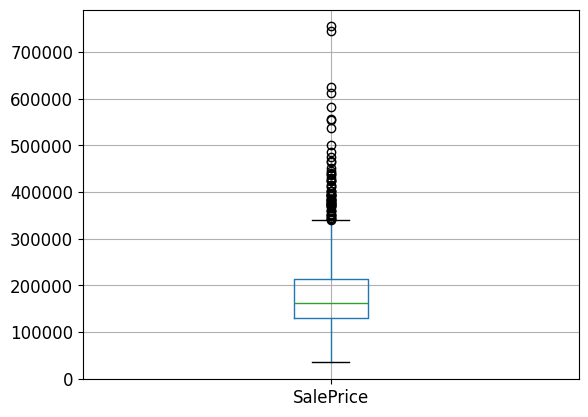

In [30]:
df.boxplot(column='SalePrice', fontsize=12, grid=True)

Como observado tanto no histograma quanto no boxplot, a variável alvo **SalePrice** apresenta uma distribuição assimétrica à direita (right-skewed), caracterizada por uma cauda mais longa em direção aos valores mais altos. Isso indica que a maioria dos imóveis possui preços concetrados em faixas menores, enquanto alguns poucos apresentam valores significativamente elevados. 

Para reduzir essa assimetria e aproximar a distribuição de uma forma mais próxima da normal, é comum aplicar uma transformação logarítmica na variável alvo. Essa transformação comprime os valores mais altos e tende a tornar a distribuição mais simétrica, o que pode melhorar o desempenho e a estabilidade dos modelos de regressão que serão usados.

<Axes: xlabel='SalePrice', ylabel='Count'>

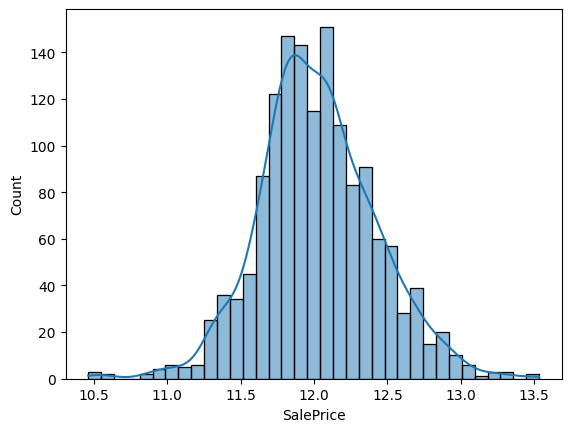

In [64]:
sns.histplot(np.log1p(df['SalePrice']), kde=True)

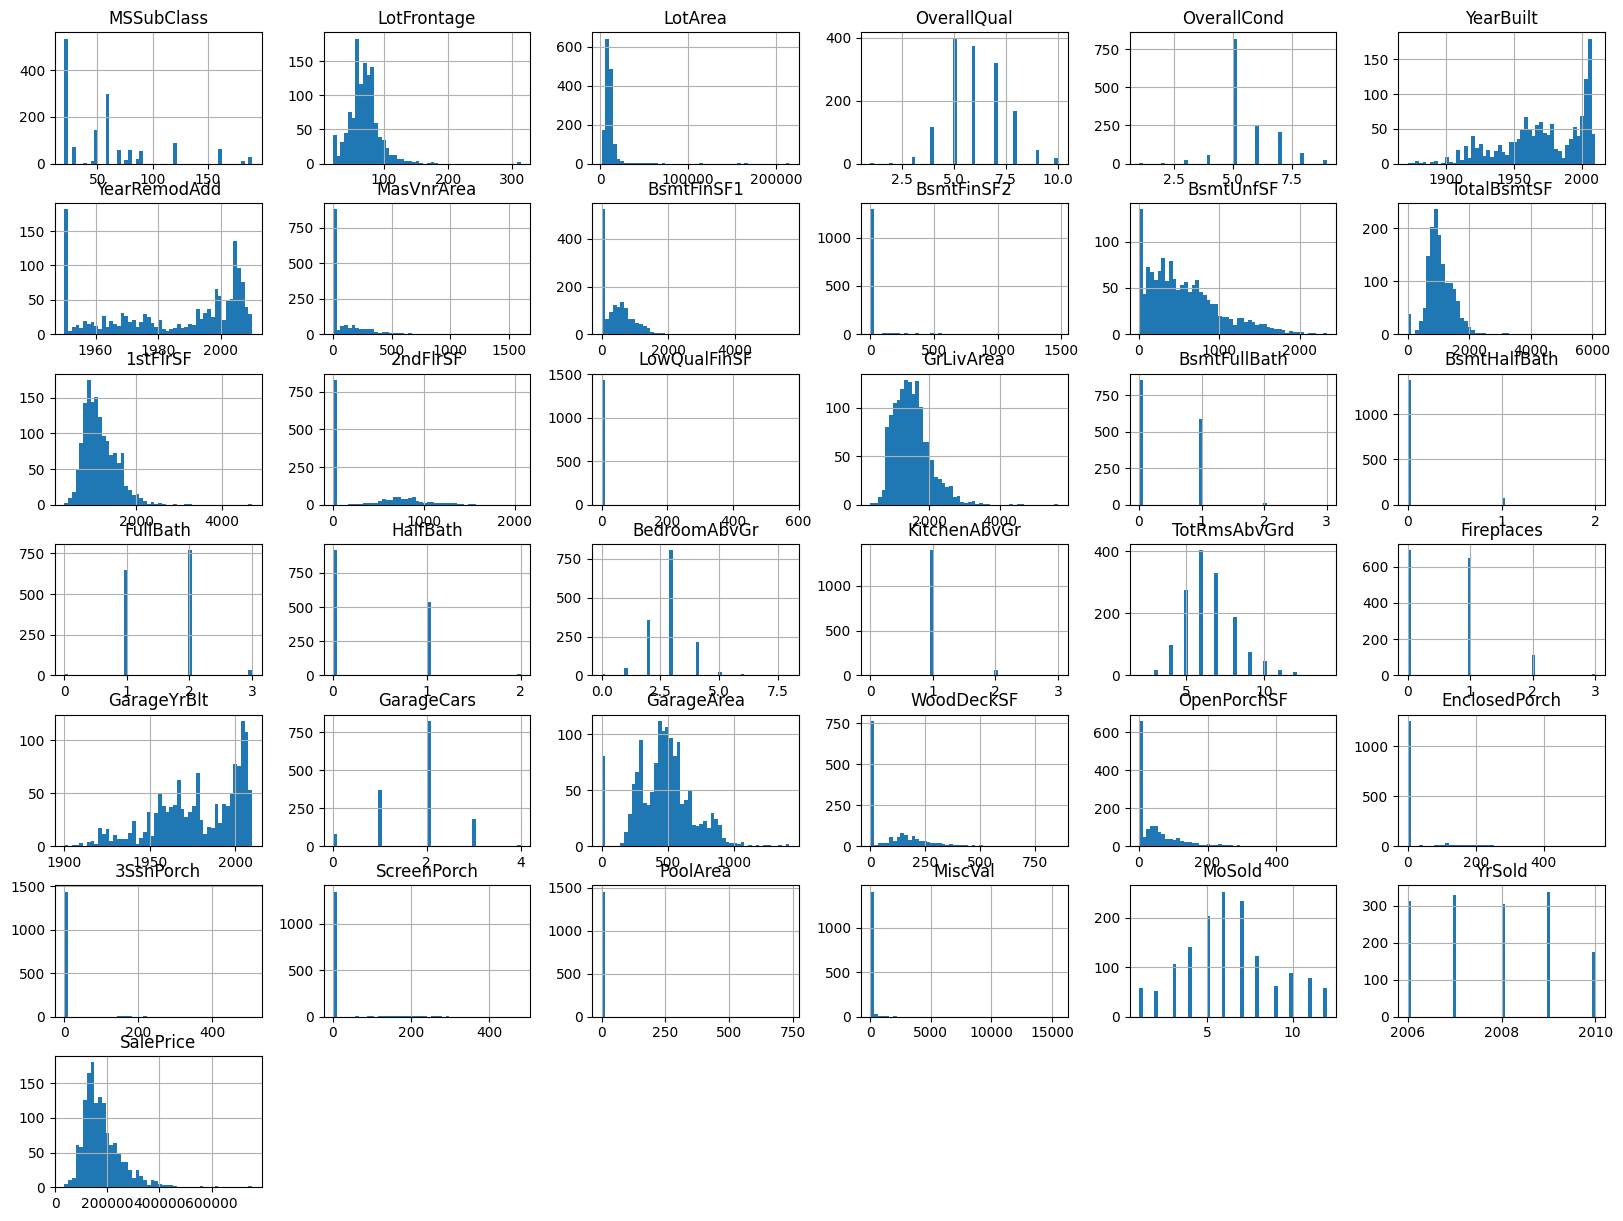

In [55]:
df.hist(bins=50, figsize=(20,15))
plt.show()